In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.config_presets.tools.load_config import load_config


config = load_config(r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\pred_RT\src\config_presets\Daniel\Uncertainty_main.yaml")


\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\pred_RT\src\config_presets\Daniel\Uncertainty_main.yaml


In [3]:
def seperate_preds_labels(df, endpoints, mode='test'):
    if mode is not None:
        df = df[df['Mode'] == mode]
    pred_columns = [col + '_pred' for col in endpoints]
    label_columns = [col + '_true' for col in endpoints]

    preds = df[pred_columns].values
    labels = df[label_columns].values

    # rename the columns in preds and labels by stripping '_pred' and '_true' from column names
    preds = pd.DataFrame(preds, columns=endpoints)
    labels = pd.DataFrame(labels, columns=endpoints)

    return preds, labels



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
10 10 10


\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\pred_RT\src\evaluation\metrics\utils.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bin_accs[bin] = (labels_oneh[binned==bin]).sum() / bin_sizes[bin]
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\pred_RT\src\evaluation\metrics\utils.py:76: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bin_confs[bin] = (y_pred[binned==bin]).sum() / bin_sizes[bin]
\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\pred_RT\src\evaluation\metrics\utils.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  bin_accs[bin] = (labels_oneh[binned==bin]).sum() / bin_sizes[bin]
\\zkh\appdata\RTDicom\Projectline_H

10 10 10
10 10 10
10 10 10
10 10 10


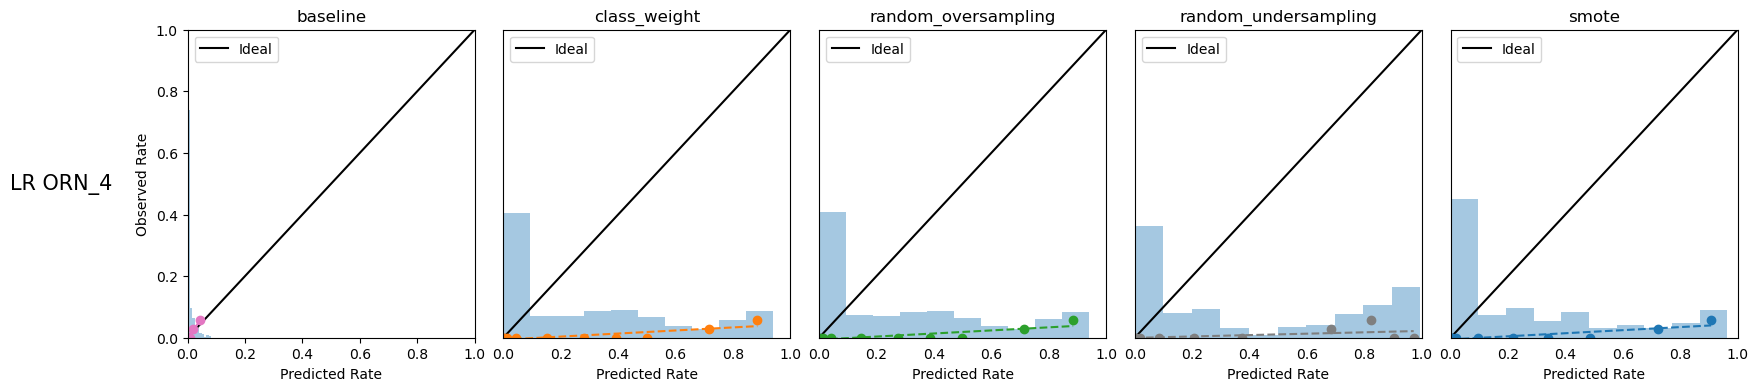

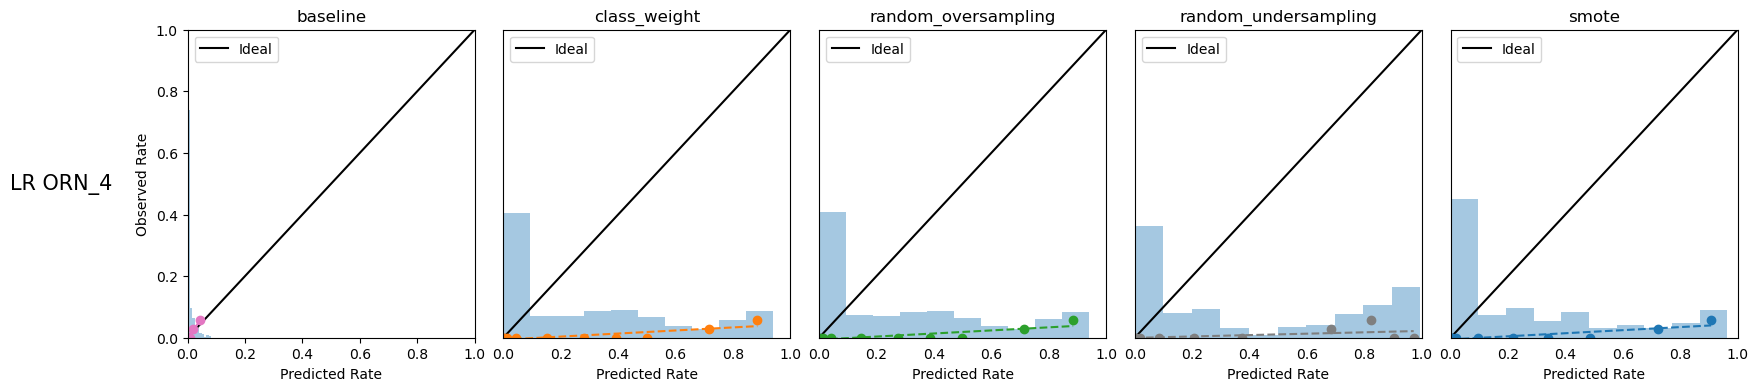

In [9]:
%load_ext autoreload
%autoreload 2

from src.visualization.calibration.adaptive_make_endpoint_plots import adaptive_make_endpoint_plots

# load datasets
data_dir = r"\\zkh\appdata\RTDicom\Projectline_HNC_modelling\Users\Daniel MacRae\6. Unbalanced dataset\rare_event_modelling\results\ORN_4"
methods = ['baseline', 'class_weight', 'random_oversampling', 'random_undersampling', 'smote']

all_preds = {}
all_labels = {}

for method in methods:
    df = pd.read_csv(f"{data_dir}/predictions_{method}.csv", sep=';')
    endpoints = ['ORN_4']
    preds, labels = seperate_preds_labels(df, endpoints, mode='test')

    all_preds[method] = preds
    all_labels[method] = labels

row_dicts = [{
    'name': "LR ORN_4",
    'preds': all_preds,
    'labels': all_labels
}]

adaptive_make_endpoint_plots(
    config,
    row_dicts=row_dicts,
    column_names=methods,
    return_fig=True,
)


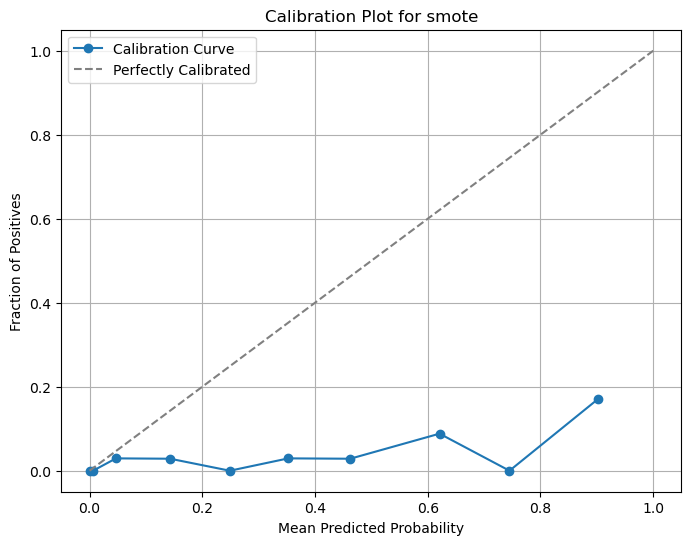

In [7]:
from sklearn.calibration import calibration_curve

# Extract predictions and true labels for the specified method
y_true = all_labels[method]['ORN_1_4']
y_prob = all_preds[method]['ORN_1_4']

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='quantile')

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title(f'Calibration Plot for {method}')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.calibration import calibration_curve

# Extract predictions and true labels for the specified method
y_true = all_labels[method]['ORN_1_4']
y_prob = all_preds[method]['ORN_1_4']

# Compute calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)

# Plot calibration curve
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title(f'Calibration Plot for {method}')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid()
plt.show()

In [5]:
config['evaluation']['visualisations']

{'list': ['calibration', 'reliability'], 'n_bins': 10}